# Deep Leakage from Gradients em Aprendizado Federado (Flower)

## Visão Geral

Este notebook demonstra o ataque **Deep Leakage from Gradients (DLG)** no contexto de
**Aprendizado Federado** usando o framework **Flower**.

Um **servidor malicioso** intercepta os gradientes de um cliente-alvo e tenta
**reconstruir os dados de treino originais** desse cliente.

### Pontos-chave para o DLG funcionar

O ataque DLG é sensível a vários fatores. Para garantir reconstrução de qualidade:

1. **Batch size = 1**: O DLG original foi projetado para reconstruir 1 imagem por vez.
   Com batches maiores a reconstrução degrada drasticamente.
2. **Gradientes exatos**: O ataque precisa dos gradientes exatos de um único forward/backward
   pass, não de pseudo-gradientes acumulados ao longo de vários steps.
3. **Modelo não treinado**: O paper mostra que o ataque funciona melhor nas primeiras rodadas,
   quando os pesos ainda estão aleatórios.
4. **Precisão numérica**: Os gradientes devem ser transmitidos sem perda de precisão.

### Arquitetura

```
┌─────────────────────────────────────────────────┐
│              SERVIDOR (DLGAttackStrategy)        │
│                                                  │
│  1. Envia parâmetros globais aos clientes        │
│  2. Recebe gradientes (não params atualizados!)  │
│  3. INTERCEPTA: pega gradientes do cliente-alvo  │
│  4. ATAQUE DLG: otimiza dummy data via LBFGS     │
│  5. Agrega normalmente (FedAvg)                  │
└──────────────┬──────────────┬────────────────────┘
               │              │
       ┌───────▼──┐    ┌──────▼───┐    ┌──────────┐
       │ Cliente 0│    │ Cliente 1│    │ Cliente 2│
       │  (ALVO)  │    │          │    │          │
       │ CIFAR-100│    │ CIFAR-100│    │ CIFAR-100│
       └──────────┘    └──────────┘    └──────────┘
```


## 1. Instalação

In [ ]:
# Descomente se precisar instalar
!pip install protobuf==5.29.3
!pip install torch torchvision flwr[simulation] matplotlib numpy Pillow


  Using cached protobuf-5.29.3-cp38-abi3-manylinux2014_x86_64.whl.metadata (592 bytes)
Using cached protobuf-5.29.3-cp38-abi3-manylinux2014_x86_64.whl (319 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.5
    Uninstalling protobuf-6.33.5:
      Successfully uninstalled protobuf-6.33.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-health-checking 1.78.0 requires protobuf<7.0.0,>=6.31.1, but you have protobuf 5.29.3 which is incompatible.


  Using cached protobuf-6.33.5-cp39-abi3-manylinux2014_x86_64.whl.metadata (593 bytes)
Using cached protobuf-6.33.5-cp39-abi3-manylinux2014_x86_64.whl (323 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.3
    Uninstalling protobuf-5.29.3:
      Successfully uninstalled protobuf-5.29.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.5 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.33.5 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.5 which is incompatible.


## 2. Imports

In [ ]:
%matplotlib inline

import os
import json
import copy
from collections import OrderedDict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import flwr as fl
from flwr.common import (
    NDArrays,
    Scalar,
    FitRes,
    Parameters,
    ndarrays_to_parameters,
    parameters_to_ndarrays,
)
from flwr.server.client_proxy import ClientProxy
from flwr.server.strategy import FedAvg

print(f"PyTorch: {torch.__version__}")
print(f"Flower:  {fl.__version__}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device:  {DEVICE}")


PyTorch: 2.10.0+cpu
Flower:  1.27.0
Device:  cpu
PyTorch: 2.10.0+cpu
Flower:  1.27.0
Device:  cpu


## 3. Configuração

**IMPORTANTE**: Para o DLG funcionar, `BATCH_SIZE` deve ser **1**.
O ataque pode funcionar com batches pequenos (2-4), mas a qualidade cai muito.

In [ ]:
# ==================== CONFIGURACAO ====================
SEED = 50
NUM_CLIENTS = 3
NUM_ROUNDS = 3
ATTACK_ROUNDS = [0, 1, 2]    # Rodadas para executar o ataque (0-indexed)
TARGET_CLIENT = 0             # ID do cliente-alvo
DLG_ITERATIONS = 300          # Iteracoes LBFGS
NUM_CLASSES = 100             # CIFAR-100
BATCH_SIZE = 1               # batch=1 para DLG funcionar
CLIENT_LR = 0.01
SAVE_DIR = "results"

torch.manual_seed(SEED)
np.random.seed(SEED)
os.makedirs(SAVE_DIR, exist_ok=True)

print("Configuracao:")
print(f"  Clientes:          {NUM_CLIENTS}")
print(f"  Rodadas:           {NUM_ROUNDS}")
print(f"  Rodadas de ataque: {ATTACK_ROUNDS}")
print(f"  Batch size:        {BATCH_SIZE}")
print(f"  DLG iteracoes:     {DLG_ITERATIONS}")


Configuracao:
  Clientes:          3
  Rodadas:           3
  Rodadas de ataque: [0, 1, 2]
  Batch size:        1
  DLG iteracoes:     300
Configuracao:
  Clientes:          3
  Rodadas:           3
  Rodadas de ataque: [0, 1, 2]
  Batch size:        1
  DLG iteracoes:     300


## 4. Modelo (LeNet)

In [ ]:
def label_to_onehot(target, num_classes=100):
    target = torch.unsqueeze(target, 1)
    onehot_target = torch.zeros(target.size(0), num_classes, device=target.device)
    onehot_target.scatter_(1, target, 1)
    return onehot_target


def cross_entropy_for_onehot(pred, target):
    return torch.mean(torch.sum(-target * F.log_softmax(pred, dim=-1), 1))


class LeNet(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        act = nn.Sigmoid
        self.body = nn.Sequential(
            nn.Conv2d(3, 12, kernel_size=5, padding=5 // 2, stride=2), act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=5 // 2, stride=2), act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=5 // 2, stride=1), act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=5 // 2, stride=1), act(),
        )
        self.fc = nn.Sequential(nn.Linear(768, num_classes))

    def forward(self, x):
        out = self.body(x)
        out = out.view(out.size(0), -1)
        return self.fc(out)


def weights_init(m):
    if hasattr(m, "weight"):
        m.weight.data.uniform_(-0.5, 0.5)
    if hasattr(m, "bias"):
        m.bias.data.uniform_(-0.5, 0.5)


def get_parameters(net):
    return [val.cpu().numpy() for _, val in net.state_dict().items()]


def set_parameters(net, parameters):
    state_dict = OrderedDict(
        {k: torch.tensor(v) for k, v in zip(net.state_dict().keys(), parameters)}
    )
    net.load_state_dict(state_dict, strict=True)


# Teste
_net = LeNet(NUM_CLASSES).to(DEVICE)
_net.apply(weights_init)
_out = _net(torch.randn(1, 3, 32, 32, device=DEVICE))
print(f"Modelo OK - output shape: {_out.shape}, params: {sum(p.numel() for p in _net.parameters()):,}")
del _net, _out


Modelo OK - output shape: torch.Size([1, 100]), params: 88,648
Modelo OK - output shape: torch.Size([1, 100]), params: 88,648


## 5. Dataset

CIFAR-100: 50000 amostras de treino


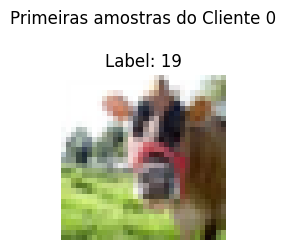

CIFAR-100: 50000 amostras de treino


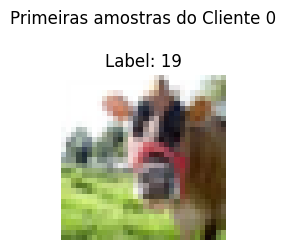

In [ ]:
tp = transforms.Compose([
    transforms.Resize(32),
    transforms.CenterCrop(32),
    transforms.ToTensor(),
])
tt = transforms.ToPILImage()

cifar100_train = datasets.CIFAR100(root="~/.torch", train=True, download=True, transform=tp)
print(f"CIFAR-100: {len(cifar100_train)} amostras de treino")


def load_partition(client_id, num_clients):
    total = len(cifar100_train)
    per_client = total // num_clients
    start = client_id * per_client
    end = start + per_client
    partition = Subset(cifar100_train, list(range(start, end)))
    return DataLoader(partition, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)


# Visualiza amostras do cliente-alvo
_loader = load_partition(TARGET_CLIENT, NUM_CLIENTS)
_imgs, _lbls = next(iter(_loader))
fig, axes = plt.subplots(1, min(4, BATCH_SIZE), figsize=(10, 2.5))
if BATCH_SIZE == 1:
    axes = [axes]
for i, ax in enumerate(axes[:_imgs.shape[0]]):
    ax.imshow(tt(_imgs[i]))
    ax.set_title(f"Label: {_lbls[i].item()}")
    ax.axis("off")
plt.suptitle(f"Primeiras amostras do Cliente {TARGET_CLIENT}")
plt.tight_layout()
plt.show()
del _loader, _imgs, _lbls


## 6. Ataque DLG

Esta e a mesma logica do notebook original.
Os gradientes sao passados como **tensores PyTorch** (sem serializacao lossy).

In [ ]:
def run_dlg_attack(
    original_gradients,   # list[torch.Tensor] - gradientes exatos
    model_state_dict,     # OrderedDict - state_dict do modelo
    num_classes=100,
    num_iters=300,
    device="cpu",
):
    # Recria modelo no estado exato
    net = LeNet(num_classes=num_classes).to(device)
    net.load_state_dict(model_state_dict)
    net.eval()

    # Garante que os gradientes originais estao no device correto
    original_gradients = [g.to(device) for g in original_gradients]

    # Dados dummy
    dummy_data = torch.randn(1, 3, 32, 32, device=device, requires_grad=True)
    dummy_label = torch.randn(1, num_classes, device=device, requires_grad=True)

    optimizer = torch.optim.LBFGS([dummy_data, dummy_label])
    criterion = cross_entropy_for_onehot

    history = []
    losses = []

    for iters in range(num_iters):
        def closure():
            optimizer.zero_grad()

            pred = net(dummy_data)
            dummy_onehot_label = F.softmax(dummy_label, dim=-1)
            dummy_loss = criterion(pred, dummy_onehot_label)

            dummy_dy_dx = torch.autograd.grad(
                dummy_loss, net.parameters(), create_graph=True
            )

            grad_diff = 0
            for gx, gy in zip(dummy_dy_dx, original_gradients):
                grad_diff += ((gx - gy) ** 2).sum()

            grad_diff.backward()
            return grad_diff

        optimizer.step(closure)

        if iters % 10 == 0:
            current_loss = closure().item()
            losses.append((iters, current_loss))
            history.append(dummy_data.detach().clone().cpu())

        if iters % 50 == 0:
            print(f"    iter {iters:>4d} | loss: {losses[-1][1] if losses else 0:.4f}")

    return {
        "reconstructed": dummy_data.detach().cpu(),
        "recon_label": torch.argmax(dummy_label.detach(), dim=-1).cpu().item(),
        "final_loss": losses[-1][1] if losses else float("inf"),
        "history": history,
        "losses": losses,
    }


print("run_dlg_attack definida!")


run_dlg_attack definida!
run_dlg_attack definida!


## 7. Cliente Flower

In [ ]:
import io
import base64


def _serialize_tensors(tensor_list):
    buf = io.BytesIO()
    torch.save(tensor_list, buf)
    return base64.b64encode(buf.getvalue()).decode("ascii")


def _deserialize_tensors(b64_string):
    buf = io.BytesIO(base64.b64decode(b64_string))
    return torch.load(buf, weights_only=True)


class CifarClient(fl.client.NumPyClient):
    def __init__(self, client_id, num_clients, device="cpu"):
        self.client_id = client_id
        self.device = device
        self.net = LeNet(num_classes=NUM_CLASSES).to(device)
        self.trainloader = load_partition(client_id, num_clients)
        self.criterion = cross_entropy_for_onehot

    def get_parameters(self, config):
        return get_parameters(self.net)

    def fit(self, parameters, config):
        set_parameters(self.net, parameters)

        capture = config.get("capture_gradients", False)
        is_target = (self.client_id == config.get("target_client", -1))

        if capture and is_target:
            return self._fit_with_gradient_capture(parameters, config)
        else:
            return self._fit_normal(parameters, config)

    def _fit_with_gradient_capture(self, parameters, config):
        # Pega o primeiro batch
        images, labels = next(iter(self.trainloader))
        images = images.to(self.device)
        labels = labels.to(self.device)
        onehot = label_to_onehot(labels, NUM_CLASSES)

        # Forward + backward para obter gradientes EXATOS
        self.net.zero_grad()
        outputs = self.net(images)
        loss = self.criterion(outputs, onehot)
        grads = torch.autograd.grad(loss, self.net.parameters())

        # Serializa gradientes + ground truth via torch.save (sem perda de precisao!)
        grad_tensors = [g.detach().cpu() for g in grads]
        gt_data = images.detach().cpu()
        gt_labels_t = labels.detach().cpu()

        payload = {
            "gradients": grad_tensors,
            "gt_data": gt_data,
            "gt_labels": gt_labels_t,
        }
        serialized = _serialize_tensors(payload)

        # Agora faz treino normal para o FedAvg funcionar
        set_parameters(self.net, parameters)
        self.net.train()
        optimizer = torch.optim.SGD(self.net.parameters(), lr=CLIENT_LR)
        num_samples = 0
        for imgs, lbls in self.trainloader:
            imgs, lbls = imgs.to(self.device), lbls.to(self.device)
            oh = label_to_onehot(lbls, NUM_CLASSES)
            optimizer.zero_grad()
            out = self.net(imgs)
            l = self.criterion(out, oh)
            l.backward()
            optimizer.step()
            num_samples += imgs.size(0)

        return (
            get_parameters(self.net),
            num_samples,
            {
                "client_id": self.client_id,
                "_payload": serialized,
            },
        )

    def _fit_normal(self, parameters, config):
        self.net.train()
        optimizer = torch.optim.SGD(self.net.parameters(), lr=CLIENT_LR)
        num_samples = 0
        total_loss = 0.0

        for images, labels in self.trainloader:
            images, labels = images.to(self.device), labels.to(self.device)
            onehot = label_to_onehot(labels, NUM_CLASSES)
            optimizer.zero_grad()
            outputs = self.net(images)
            loss = self.criterion(outputs, onehot)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * images.size(0)
            num_samples += images.size(0)

        return (
            get_parameters(self.net),
            num_samples,
            {"client_id": self.client_id, "loss": total_loss / max(num_samples, 1)},
        )

    def evaluate(self, parameters, config):
        set_parameters(self.net, parameters)
        self.net.eval()
        correct, total, total_loss = 0, 0, 0.0
        with torch.no_grad():
            for images, labels in self.trainloader:
                images, labels = images.to(self.device), labels.to(self.device)
                onehot = label_to_onehot(labels, NUM_CLASSES)
                outputs = self.net(images)
                loss = self.criterion(outputs, onehot)
                total_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        return total_loss / max(total, 1), total, {"accuracy": correct / max(total, 1)}


def create_client_fn(num_clients, device="cpu"):
    def client_fn(context):
        client_id = int(context.node_id) % num_clients
        return CifarClient(client_id, num_clients, device).to_client()
    return client_fn


print("CifarClient definido!")
print(f"  Serializacao: torch.save/load (precisao total)")
print(f"  Batch size: {BATCH_SIZE}")


CifarClient definido!
  Serializacao: torch.save/load (precisao total)
  Batch size: 1
CifarClient definido!
  Serializacao: torch.save/load (precisao total)
  Batch size: 1


## 8. DLGAttackStrategy

O servidor intercepta os gradientes do cliente-alvo e executa o ataque DLG.



In [ ]:
class DLGAttackStrategy(FedAvg):

    def __init__(self, target_client_id=0, attack_rounds=None,
                 dlg_iterations=300, num_classes=100, save_dir="results", **kwargs):
        super().__init__(**kwargs)
        self.target_client_id = target_client_id
        self.attack_rounds = attack_rounds or [0]
        self.dlg_iterations = dlg_iterations
        self.num_classes = num_classes
        self.save_dir = save_dir
        self.attack_results = []
        # Armazena para visualizacao
        self.gt_store = {}
        self.recon_store = {}
        os.makedirs(save_dir, exist_ok=True)

        # O state_dict do modelo global que foi enviado aos clientes nesta rodada.
        # Precisamos dele para recriar o modelo exato no ataque DLG.
        self._current_global_state_dict = None

    def initialize_parameters(self, client_manager):
        params = super().initialize_parameters(client_manager)
        # Salva o state dict inicial
        if params is not None:
            self._save_global_state(params)
        return params

    def _save_global_state(self, parameters):
        ndarrays = parameters_to_ndarrays(parameters)
        net = LeNet(num_classes=self.num_classes)
        set_parameters(net, ndarrays)
        self._current_global_state_dict = copy.deepcopy(net.state_dict())

    def aggregate_fit(self, server_round, results, failures):
        print(f"\n{'='*60}")
        print(f"  RODADA {server_round}")
        print(f"{'='*60}")

        should_attack = (server_round - 1) in self.attack_rounds

        if should_attack:
            print(f"  [!] Executando ataque DLG!")
            self._execute_attack(server_round, results)

        # Agregacao normal
        aggregated = super().aggregate_fit(server_round, results, failures)

        # Atualiza o state dict global para a proxima rodada
        if aggregated[0] is not None:
            self._save_global_state(aggregated[0])

        return aggregated

    def _execute_attack(self, server_round, results):
        # Procura cliente-alvo
        target_metrics = None
        for _, fit_res in results:
            metrics = fit_res.metrics or {}
            if metrics.get("client_id", -1) == self.target_client_id:
                target_metrics = metrics
                break

        if target_metrics is None or "_payload" not in target_metrics:
            print(f"  [!] Cliente-alvo nao encontrado ou sem payload.")
            return

        # Desserializa gradientes (precisao total!)
        payload = _deserialize_tensors(target_metrics["_payload"])
        gradients = payload["gradients"]
        gt_data = payload["gt_data"]
        gt_labels = payload["gt_labels"]

        print(f"  [+] Gradientes recebidos: {len(gradients)} tensores")
        print(f"  [+] GT shape: {gt_data.shape}, labels: {gt_labels.tolist()}")
        print(f"  [+] Grad norm: {sum(g.norm().item() for g in gradients):.4f}")

        # Usa o state_dict exato que foi enviado ao cliente
        if self._current_global_state_dict is None:
            print("  [!] State dict global nao disponivel.")
            return

        print(f"  [+] Executando DLG ({self.dlg_iterations} iters)...")
        result = run_dlg_attack(
            original_gradients=gradients,
            model_state_dict=self._current_global_state_dict,
            num_classes=self.num_classes,
            num_iters=self.dlg_iterations,
            device="cpu",
        )

        self.recon_store[server_round] = result
        self.gt_store[server_round] = {"data": gt_data, "labels": gt_labels}

        self.attack_results.append({
            "round": server_round,
            "final_loss": result["final_loss"],
            "gt_label": gt_labels.tolist(),
            "recon_label": result["recon_label"],
        })

        print(f"  [+] Loss final: {result['final_loss']:.6f}")
        print(f"  [+] GT label:    {gt_labels.tolist()}")
        print(f"  [+] Recon label: {result['recon_label']}")


print("DLGAttackStrategy definida!")


DLGAttackStrategy definida!
DLGAttackStrategy definida!


## 9. Execucao da Simulacao

In [ ]:
torch.manual_seed(SEED)
np.random.seed(SEED)

# Modelo global inicial (mesma init do notebook original)
net_init = LeNet(num_classes=NUM_CLASSES)
net_init.apply(weights_init)
initial_params = get_parameters(net_init)

strategy = DLGAttackStrategy(
    target_client_id=TARGET_CLIENT,
    attack_rounds=ATTACK_ROUNDS,
    dlg_iterations=DLG_ITERATIONS,
    num_classes=NUM_CLASSES,
    save_dir=SAVE_DIR,
    fraction_fit=1.0,
    fraction_evaluate=0.0,  # Sem avaliacao para ir mais rapido
    min_fit_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    initial_parameters=ndarrays_to_parameters(initial_params),
    on_fit_config_fn=lambda rnd: {
        "capture_gradients": (rnd - 1) in ATTACK_ROUNDS,
        "target_client": TARGET_CLIENT,
        "round": rnd,
    },
)

print("Iniciando simulacao Flower...\n")

hist = fl.simulation.start_simulation(
    client_fn=create_client_fn(NUM_CLIENTS, DEVICE),
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=NUM_ROUNDS),
    strategy=strategy,
    client_resources={"num_cpus": 1, "num_gpus": 0.0},
)

print("\nSimulacao concluida!")
print(f"Ataques executados: {len(strategy.attack_results)}")


Iniciando simulacao Flower...



AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

INFO :      aggregate_fit: received 3 results and 0 failures



  RODADA 3
  [!] Executando ataque DLG!
  [+] Gradientes recebidos: 10 tensores
  [+] GT shape: torch.Size([1, 3, 32, 32]), labels: [19]
  [+] Grad norm: 6.8395
  [+] Executando DLG (300 iters)...
    iter    0 | loss: 2.1723
    iter   50 | loss: 0.0009
    iter  100 | loss: 0.0001
    iter  150 | loss: 0.0000
    iter  200 | loss: 0.0000
    iter  250 | loss: 0.0000


INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 3 round(s) in 744.83s
INFO :      


  [+] Loss final: 0.000003
  [+] GT label:    [19]
  [+] Recon label: 19

Simulacao concluida!
Ataques executados: 3


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 10. Resultados

### 10.1 Comparacao Ground Truth vs Reconstrucao

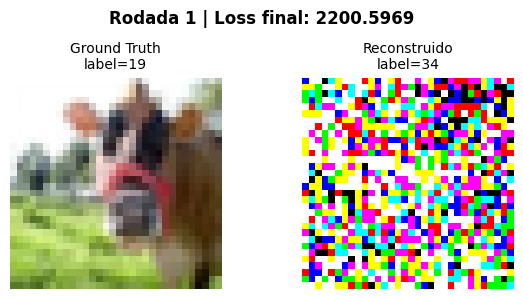

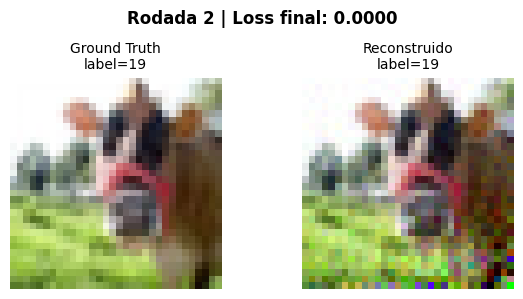

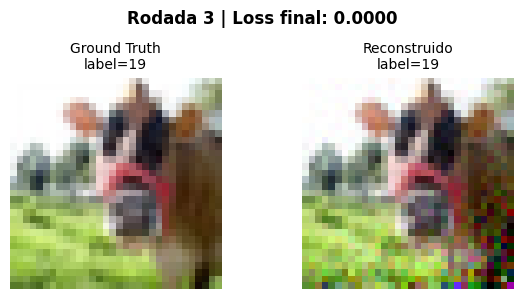

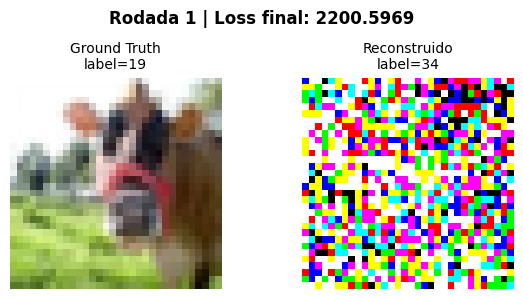

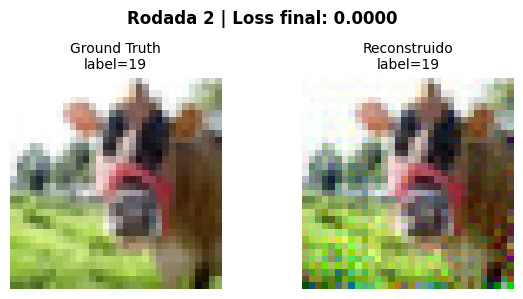

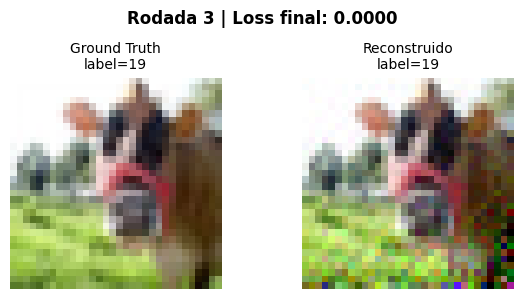

In [ ]:
for rnd in sorted(strategy.recon_store.keys()):
    recon = strategy.recon_store[rnd]
    gt = strategy.gt_store[rnd]

    gt_img = gt["data"][0]  # [3, 32, 32]
    gt_label = gt["labels"][0].item()
    recon_img = recon["reconstructed"][0]  # [3, 32, 32]
    recon_label = recon["recon_label"]

    fig, axes = plt.subplots(1, 2, figsize=(6, 3))

    axes[0].imshow(gt_img.clamp(0, 1).permute(1, 2, 0).numpy())
    axes[0].set_title(f"Ground Truth\nlabel={gt_label}", fontsize=10)
    axes[0].axis("off")

    axes[1].imshow(recon_img.clamp(0, 1).permute(1, 2, 0).numpy())
    axes[1].set_title(f"Reconstruido\nlabel={recon_label}", fontsize=10)
    axes[1].axis("off")

    plt.suptitle(f"Rodada {rnd} | Loss final: {recon['final_loss']:.4f}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


### 10.2 Evolucao da Reconstrucao por Iteracao

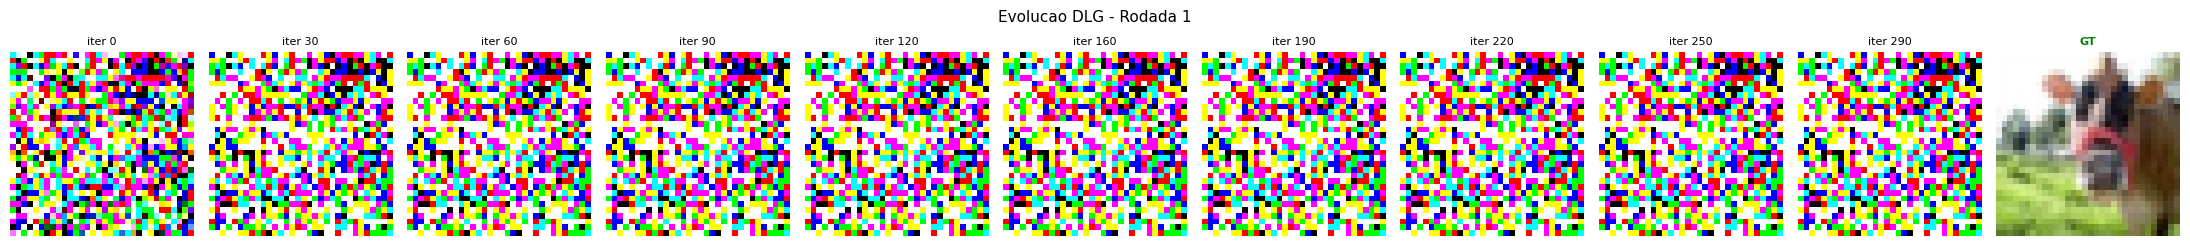

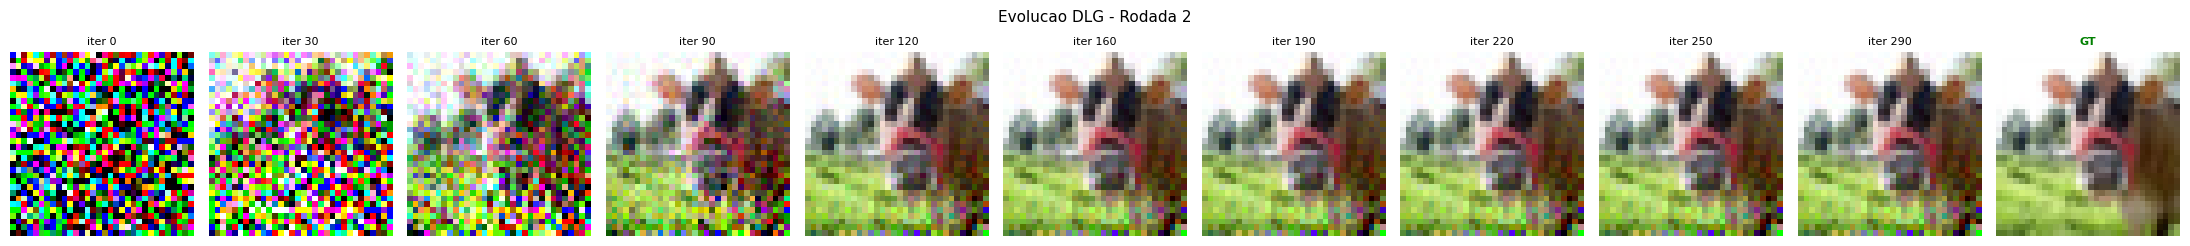

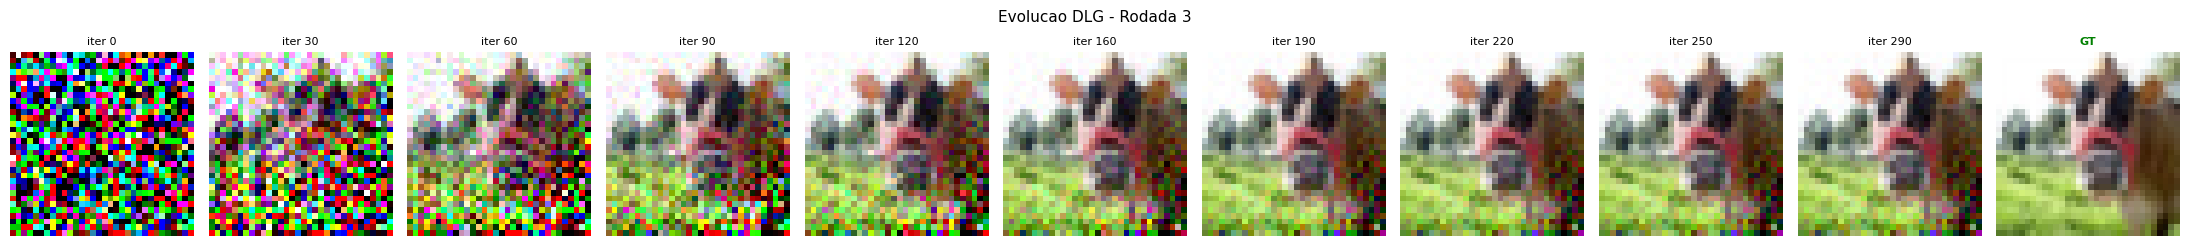

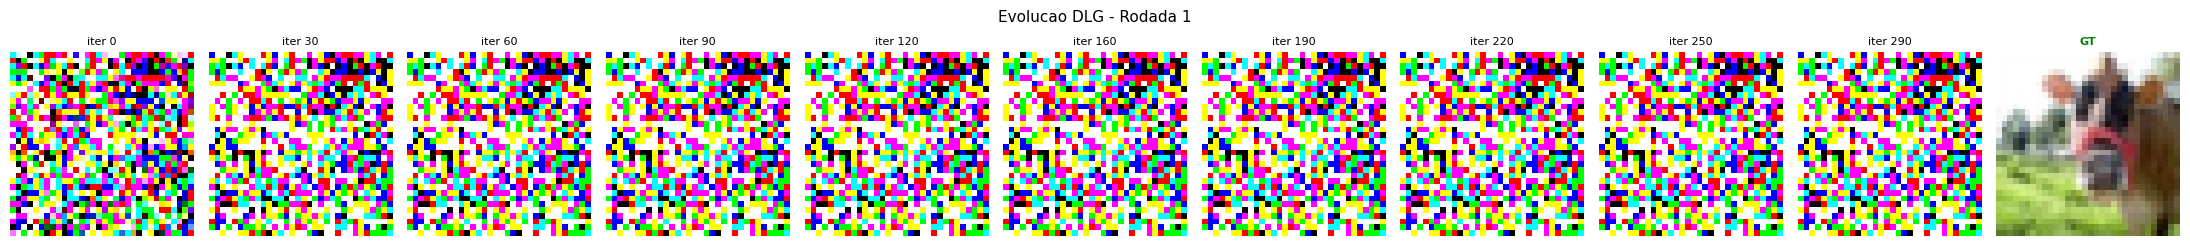

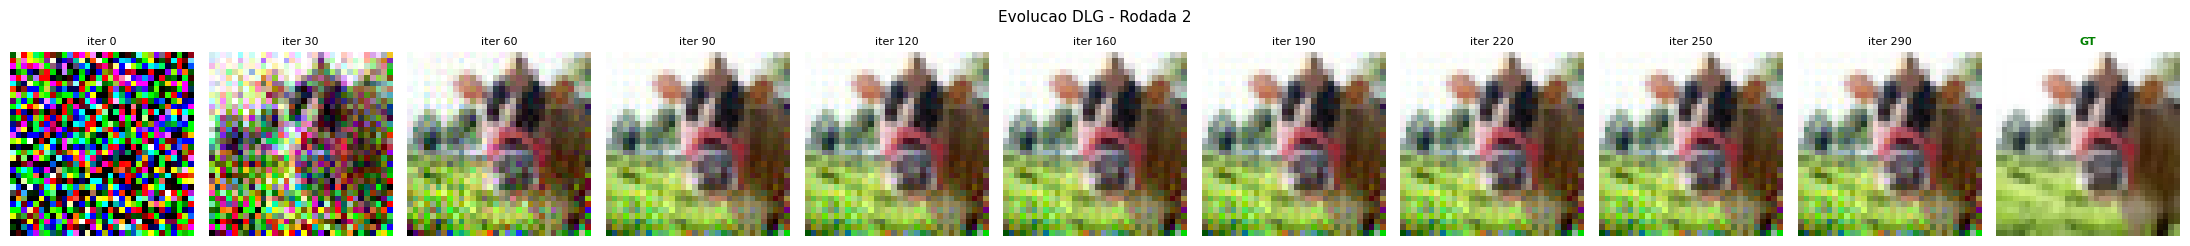

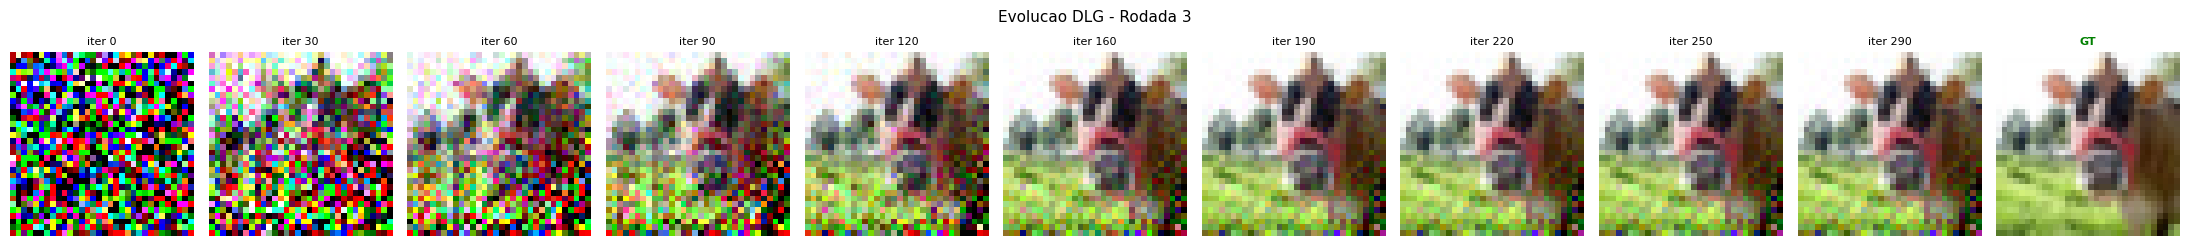

In [ ]:
for rnd in sorted(strategy.recon_store.keys()):
    recon = strategy.recon_store[rnd]
    hist = recon["history"]
    gt = strategy.gt_store[rnd]

    if not hist:
        continue

    n = min(len(hist), 10)
    idx = [int(i * (len(hist) - 1) / (n - 1)) for i in range(n)]

    # +1 para o GT no final
    fig, axes = plt.subplots(1, n + 1, figsize=(2 * (n + 1), 2.5))

    for ax, j in zip(axes[:-1], idx):
        img = hist[j][0].clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(f"iter {j * 10}", fontsize=8)
        ax.axis("off")

    # GT como referencia
    gt_img = gt["data"][0].clamp(0, 1).permute(1, 2, 0).numpy()
    axes[-1].imshow(gt_img)
    axes[-1].set_title("GT", fontsize=8, fontweight="bold", color="green")
    axes[-1].axis("off")

    plt.suptitle(f"Evolucao DLG - Rodada {rnd}", fontsize=11)
    plt.tight_layout()
    plt.show()


### 10.3 Convergencia da Loss

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

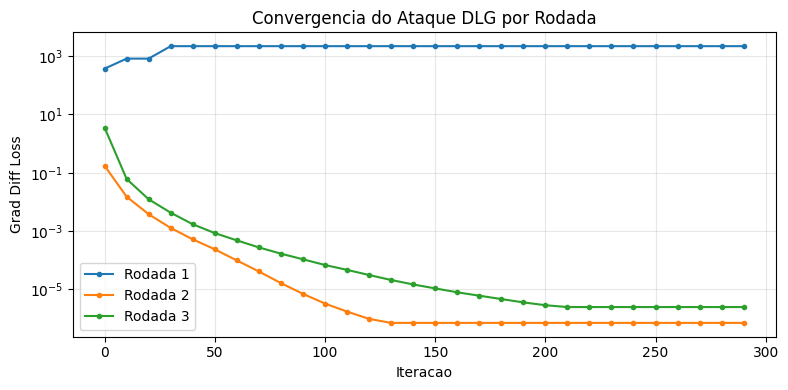

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


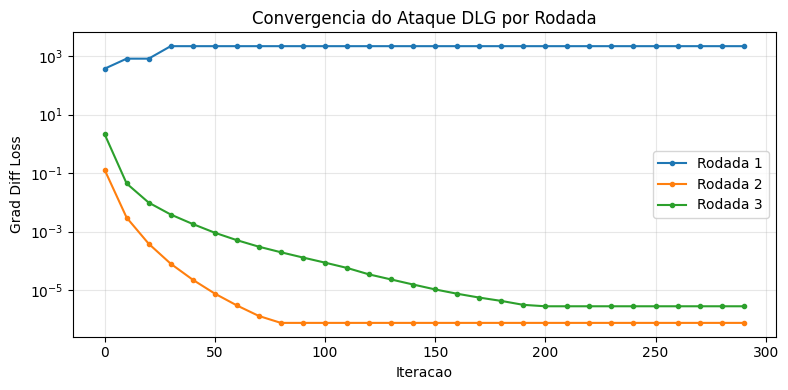

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

for rnd in sorted(strategy.recon_store.keys()):
    recon = strategy.recon_store[rnd]
    if recon["losses"]:
        iters, vals = zip(*recon["losses"])
        ax.plot(iters, vals, "-o", markersize=3, label=f"Rodada {rnd}")

ax.set_xlabel("Iteracao")
ax.set_ylabel("Grad Diff Loss")
ax.set_title("Convergencia do Ataque DLG por Rodada")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 10.4 Resumo

In [ ]:
print("=" * 60)
print("  RESUMO DOS ATAQUES")
print("=" * 60)

for res in strategy.attack_results:
    rnd = res["round"]
    label_match = "SIM" if res["gt_label"][0] == res["recon_label"] else "NAO"
    print(f"\n  Rodada {rnd}:")
    print(f"    Loss final:    {res['final_loss']:.6f}")
    print(f"    GT label:      {res['gt_label']}")
    print(f"    Recon label:   {res['recon_label']}")
    print(f"    Label correto: {label_match}")

# Salva resumo
summary = {
    "config": {
        "num_clients": NUM_CLIENTS, "num_rounds": NUM_ROUNDS,
        "attack_rounds": ATTACK_ROUNDS, "batch_size": BATCH_SIZE,
        "dlg_iterations": DLG_ITERATIONS, "seed": SEED,
    },
    "results": strategy.attack_results,
}
with open(os.path.join(SAVE_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(f"\nSalvo em {SAVE_DIR}/summary.json")


  RESUMO DOS ATAQUES

  Rodada 1:
    Loss final:    2200.596924
    GT label:      [19]
    Recon label:   34
    Label correto: NAO

  Rodada 2:
    Loss final:    0.000001
    GT label:      [19]
    Recon label:   19
    Label correto: SIM

  Rodada 3:
    Loss final:    0.000002
    GT label:      [19]
    Recon label:   19
    Label correto: SIM

Salvo em results/summary.json
  RESUMO DOS ATAQUES

  Rodada 1:
    Loss final:    2200.596924
    GT label:      [19]
    Recon label:   34
    Label correto: NAO

  Rodada 2:
    Loss final:    0.000001
    GT label:      [19]
    Recon label:   19
    Label correto: SIM

  Rodada 3:
    Loss final:    0.000003
    GT label:      [19]
    Recon label:   19
    Label correto: SIM

Salvo em results/summary.json


## 11. Teste de Sanidade: DLG Standalone (sem Flower)

Para confirmar que o ataque funciona, rodamos o DLG puro (como no seu notebook original)
usando uma unica imagem do CIFAR-100 e o mesmo modelo.

=== Teste Standalone (sem Flower) ===

Imagem: label=19


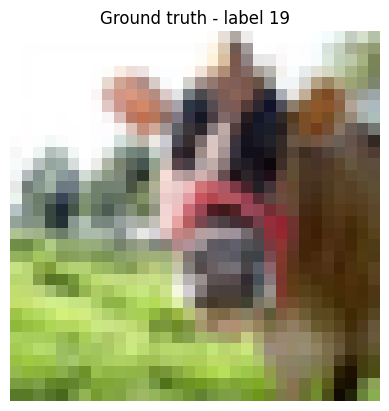

    iter    0 | loss: 119.8759
    iter   50 | loss: 0.1467
    iter  100 | loss: 0.0005
    iter  150 | loss: 0.0000
    iter  200 | loss: 0.0000
    iter  250 | loss: 0.0000


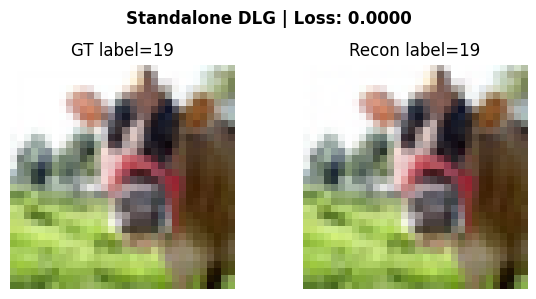


Loss final: 0.000004
Label: GT=19, Recon=19
=== Teste Standalone (sem Flower) ===

Imagem: label=19


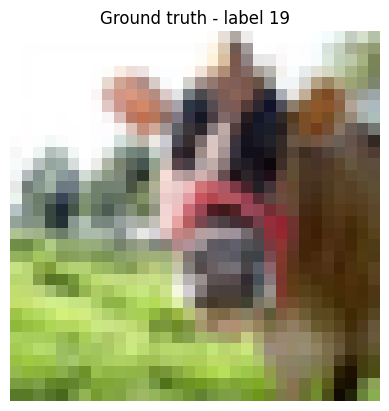

    iter    0 | loss: 119.8759
    iter   50 | loss: 0.1467
    iter  100 | loss: 0.0005
    iter  150 | loss: 0.0000
    iter  200 | loss: 0.0000
    iter  250 | loss: 0.0000


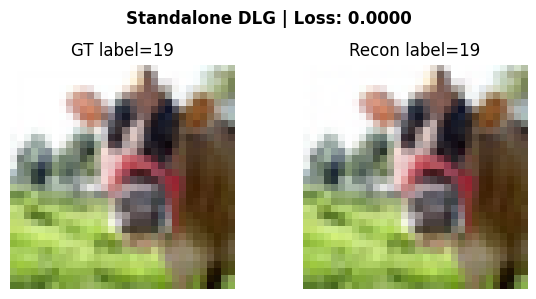


Loss final: 0.000004
Label: GT=19, Recon=19


In [ ]:
print("=== Teste Standalone (sem Flower) ===\n")

torch.manual_seed(SEED)
net_standalone = LeNet(num_classes=NUM_CLASSES).to(DEVICE)
net_standalone.apply(weights_init)

# Pega 1 imagem
img, label = cifar100_train[0]
gt_data = img.unsqueeze(0).to(DEVICE)
gt_label = torch.tensor([label]).to(DEVICE)
gt_onehot = label_to_onehot(gt_label, NUM_CLASSES)

print(f"Imagem: label={label}")
plt.imshow(tt(gt_data[0].cpu()))
plt.title(f"Ground truth - label {label}")
plt.axis("off")
plt.show()

# Gradientes exatos
out = net_standalone(gt_data)
y = cross_entropy_for_onehot(out, gt_onehot)
dy_dx = torch.autograd.grad(y, net_standalone.parameters())
original_dy_dx = [g.detach().clone() for g in dy_dx]

# Ataque DLG
result_standalone = run_dlg_attack(
    original_gradients=original_dy_dx,
    model_state_dict=copy.deepcopy(net_standalone.state_dict()),
    num_classes=NUM_CLASSES,
    num_iters=300,
    device=DEVICE,
)

# Resultado
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(gt_data[0].cpu().clamp(0,1).permute(1,2,0).numpy())
axes[0].set_title(f"GT label={label}")
axes[0].axis("off")
axes[1].imshow(result_standalone["reconstructed"][0].clamp(0,1).permute(1,2,0).numpy())
axes[1].set_title(f"Recon label={result_standalone['recon_label']}")
axes[1].axis("off")
plt.suptitle(f"Standalone DLG | Loss: {result_standalone['final_loss']:.4f}", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nLoss final: {result_standalone['final_loss']:.6f}")
print(f"Label: GT={label}, Recon={result_standalone['recon_label']}")
